In [1]:
from posandnegfunctions_0203 import *
import networkx as nx

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
gu_data = pd.read_csv("../../../../Try_3_RNAseq/Raw_Canonical/Gu_canonical_raw_tpm.csv")
guan_data = pd.read_csv("../../../../Try_3_RNAseq/Raw_Canonical/Guan_canonical_raw_tpm.csv")
chen_data = pd.read_csv("../../../../Try_3_RNAseq/Raw_Canonical/Chen_canonical_raw_tpm.csv")
zhao_data = pd.read_csv("../../../../Try_3_RNAseq/Raw_Canonical/Zhao_canonical_raw_tpm.csv")

sg_list = pd.read_csv("../../../../Try_3_RNAseq/starch_genes_new_noD_no_regs.csv")["Transcript"].tolist()
sg_all = pd.read_csv("../../../../Try_3_RNAseq/starch_genes_new_noD_no_regs.csv")

In [5]:
len(sg_list)

154

In [31]:
sg_all.head()

,Gene_ID,Transcript,function
0,cPGI-A1,TraesCS1A03G0096700,ADP-glucose metabolism
1,cPGI-B1,TraesCS1B03G0121200,ADP-glucose metabolism
2,pPGI-A1,TraesCS5A03G0618000,ADP-glucose metabolism
3,pPGI-B1,TraesCS5B03G0634900,ADP-glucose metabolism
4,PGM-A1,TraesCS4A03G0694400,ADP-glucose metabolism


In [4]:
ready_chen_no_correct = df_to_readydf(chen_data, 1, correct_sigmas = False)
ready_gu_no_correct = df_to_readydf(gu_data, 1, correct_sigmas = False)
ready_guan_no_correct = df_to_readydf(guan_data, 1, correct_sigmas = False)
ready_zhao_no_correct = df_to_readydf(zhao_data, 1, correct_sigmas = False)




In [5]:
chen_network_no_correct = df_to_BFs(sg_list, ready_chen_no_correct, 30000, mode='positive')
gu_network_no_correct = df_to_BFs(sg_list, ready_gu_no_correct, 30000, mode='positive')
guan_network_no_correct = df_to_BFs(sg_list, ready_guan_no_correct, 30000, mode='positive')
zhao_network_no_correct = df_to_BFs(sg_list, ready_zhao_no_correct, 30000, mode='positive')

In [6]:
zhao_network_no_correct.shape

(91, 91)

In [6]:
network_list = [chen_network_no_correct, gu_network_no_correct, guan_network_no_correct, zhao_network_no_correct]
combined_sge_network=combine_networks(network_list)

In [7]:
combined_sge_network.shape

(128, 128)

In [7]:
combined_sge_network.to_csv("full_sge_network_filt1.csv", index = False)


In [8]:
combined_no_correct_ccc = combined_sge_network.copy()


#### doing hierarchical clustering of the network

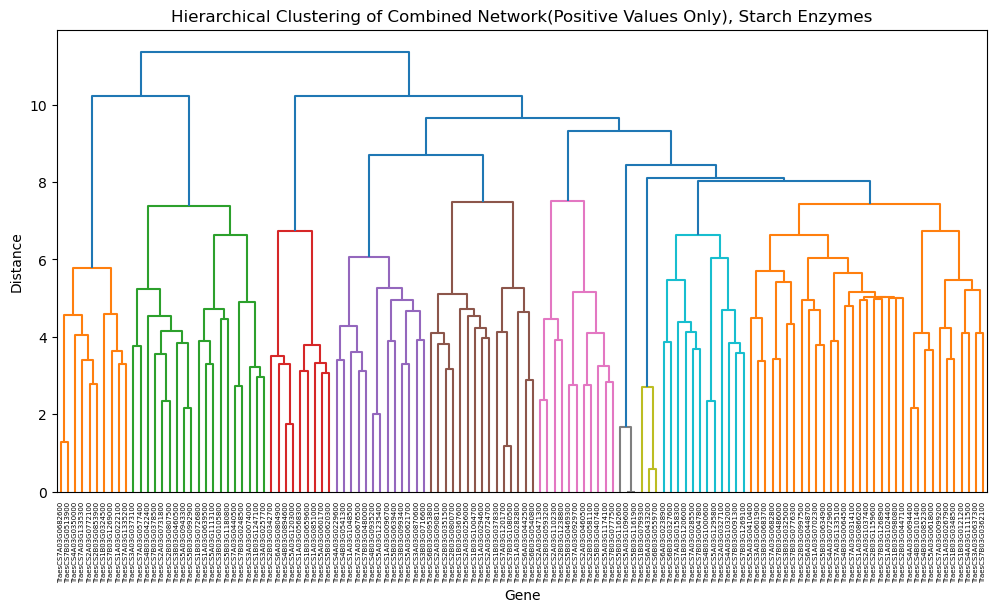

In [9]:
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from scipy.spatial.distance import squareform

# Use your gene × gene matrix (index = genes)
df_no_correct = combined_no_correct_ccc.copy()

# --- Step 1: Handle missing / infinite values
df_no_correct.replace([np.inf, -np.inf], np.nan, inplace=True)
df_no_correct.fillna(0, inplace=True)

# --- Step 2: Keep only positive values
df_no_correct_pos = df_no_correct.clip(lower=0)

# --- Step 3: Convert similarity → distance
max_val_no_correct = df_no_correct_pos.values.max()
dist_matrix_no_correct = max_val_no_correct - df_no_correct_pos.values  # higher similarity → smaller distance

# --- Step 4: Ensure all distances are finite
if not np.all(np.isfinite(dist_matrix_no_correct)):
    raise ValueError("Distance matrix contains non-finite values!")

# --- Step 5: Convert to condensed distance matrix
dist_condensed_no_correct = squareform(dist_matrix_no_correct, checks=False)

# --- Step 6: Hierarchical clustering
Z = linkage(dist_condensed_no_correct, method='ward')

# --- Step 7: Plot dendrogram (and define the SAME threshold used for clustering)
ct = 0.7 * np.max(Z[:, 2])   # this is scipy dendrogram default threshold

plt.figure(figsize=(12, 6))
dendrogram(
    Z,
    labels=df_no_correct.index,
    leaf_rotation=90,
    color_threshold=ct
)
plt.title("Hierarchical Clustering of Combined Network(Positive Values Only), Starch Enzymes")
plt.xlabel("Gene")
plt.ylabel("Distance")
plt.savefig("dendrogram.pdf", dpi=300, bbox_inches="tight")
plt.show()

# --- Step 8: Create flat clusters that MATCH dendrogram colours
cluster_labels_no_correct = fcluster(Z, t=ct, criterion="distance")
df_no_correct["cluster"] = cluster_labels_no_correct

df_reordered_no_correct = df_no_correct.sort_values("cluster")


In [21]:
df_reordered_no_correct.head()

Gene,TraesCS1A03G0096700,TraesCS1A03G0222100,TraesCS1A03G0267900,TraesCS1A03G0282800,TraesCS1A03G0294600,TraesCS1A03G0568300,TraesCS1A03G0639500,TraesCS1A03G0702300,TraesCS1A03G0851000,TraesCS1A03G0866200,...,TraesCS7B03G0480000,TraesCS7B03G0486000,TraesCS7B03G0513900,TraesCS7B03G0776300,TraesCS7B03G0777500,TraesCS7B03G1080500,TraesCS7B03G1268900,TraesCS7B03G1269000,TraesCS7B03G1269100,cluster
Gene,,,,,,,,,,,,,,,,,,,,,
TraesCS7A03G1335200,-12.559719,1.702701,-6.840252,-4.217701,-8.024996,-7.877420,0.071420,-1.809318,-5.902002,0.006719,...,-8.800260,-4.282048,1.351735,-4.182096,-5.504314,-10.878867,0.017240,1.446420,0.109374,1
TraesCS4A03G0350000,-10.893809,0.895114,-6.108120,-3.614230,-6.807314,-7.779058,0.221784,-0.825199,-5.922666,0.059222,...,-7.444911,-3.135109,1.027601,-4.051355,-5.616790,-8.963236,0.007279,0.631946,-0.820544,1
TraesCS7A03G0682600,-14.387949,0.708147,-7.304176,-5.070089,-7.724003,-31.246979,0.293817,-3.485456,-29.760312,-0.065262,...,-8.403619,-7.382101,3.746084,-4.026617,-6.815381,-13.031259,0.024296,0.795158,0.200136,1
TraesCS1B03G0324500,-7.695293,1.532030,-3.412608,-2.023097,-4.574952,-28.993058,-0.207424,-1.394092,-28.085440,0.068035,...,-4.560862,-4.018828,0.357246,-2.799073,-2.714856,-7.522845,-0.059594,0.516079,-0.285702,1
TraesCS7B03G1269000,-4.525591,1.468583,-1.071795,-2.401752,-0.425924,-11.754584,0.354939,-1.604075,-11.278122,-0.036380,...,-0.597033,-3.581054,0.702064,0.000000,-2.564496,-5.248034,0.022300,0.000000,-0.156904,1


In [28]:
df_reordered_no_correct.to_csv("reordered_combined_network_with-clusters.csv")

/var/folders/ky/6fks9zq96wnc1dytmwwmkrrw000f76/T/ipykernel_22000/890727470.py:44: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_map = plt.cm.get_cmap("tab20", len(unique_clusters))


(np.float64(-0.7827999637901574),
 np.float64(0.9336263535752147),
 np.float64(-1.189453747885845),
 np.float64(0.9937751563224629))

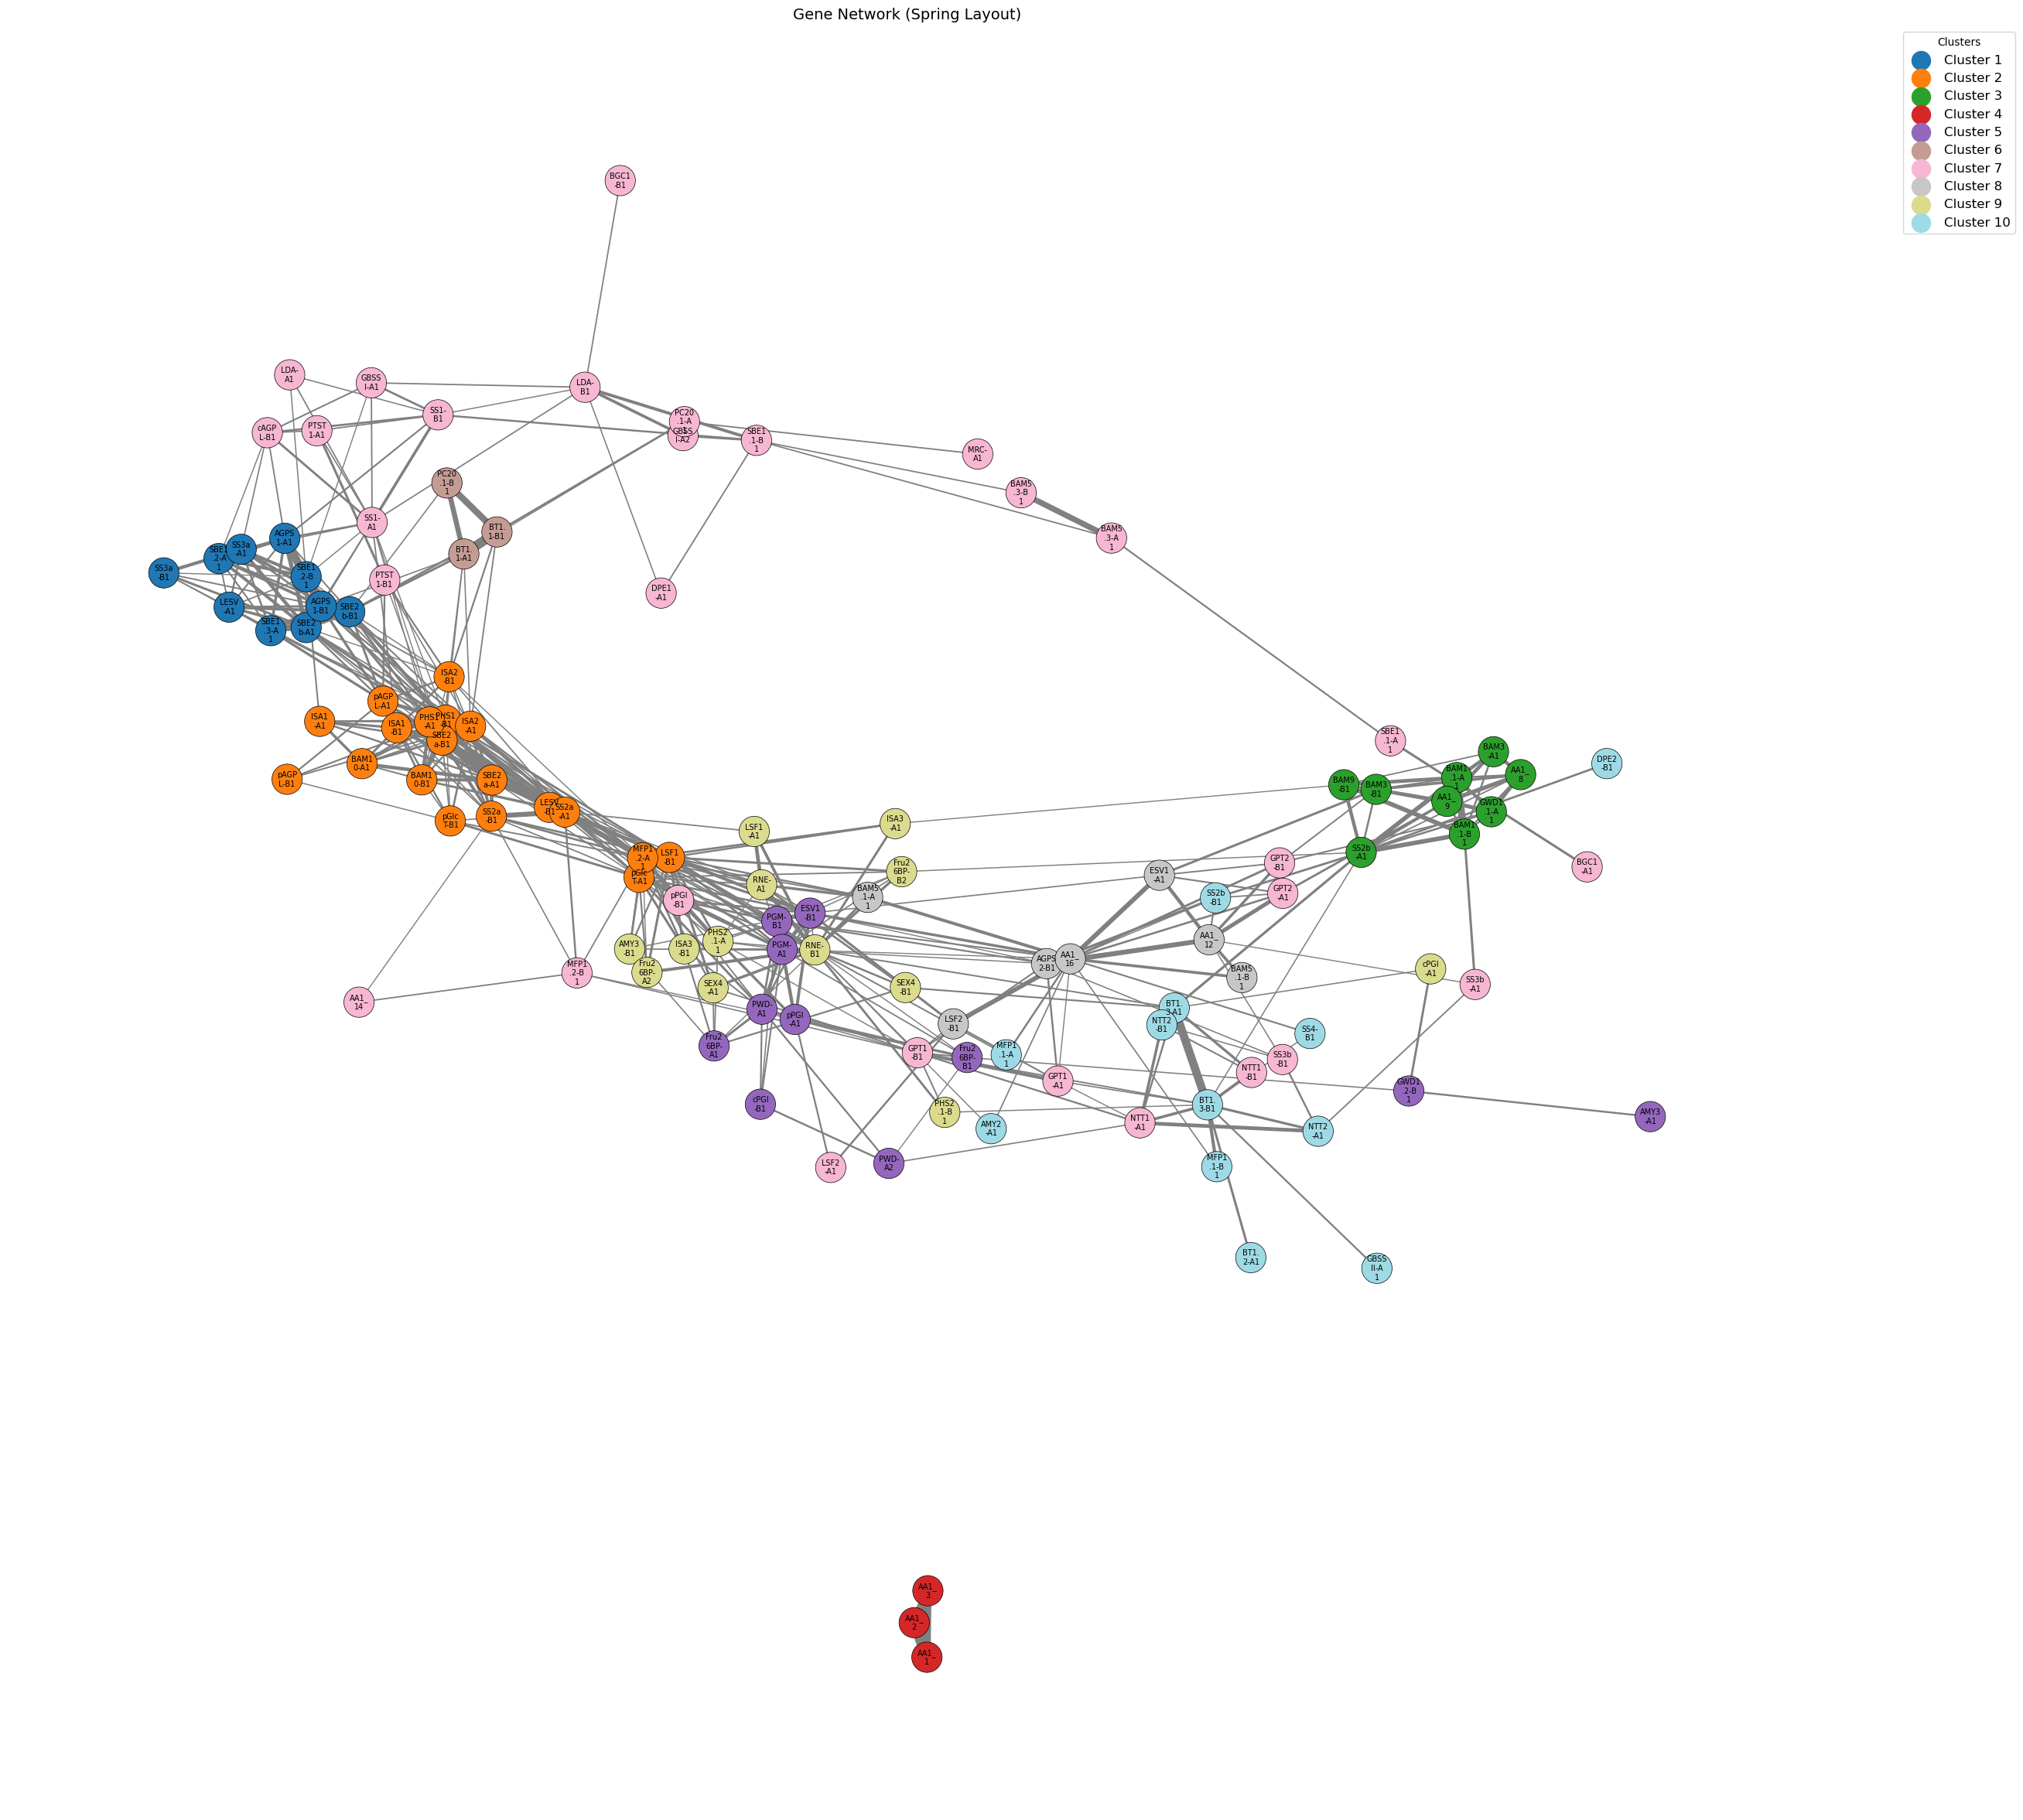

In [36]:
# --- Step 0: Merge cluster info onto sg_all to get Gene_ID labels ---
sg_with_clusters = pd.merge(
    sg_all,
    df_reordered_no_correct[["cluster"]].reset_index().rename(columns={"index":"Gene"}),
    left_on="Transcript",
    right_on="Gene",
    how="inner"
)
# sg_with_clusters now has columns: Transcript, Gene_ID, cluster, Gene

# --- Step 1: Prepare matrix for edges ---
df_matrix = df_reordered_no_correct.drop(columns="cluster")  # index = Gene
mask = df_matrix > 0.5
filtered_matrix = df_matrix.where(mask, 0)

# --- Step 2: Build graph ---
G = nx.Graph()

# Create mapping from Gene (matrix index) → Gene_ID (node label)
gene_to_id = dict(zip(sg_with_clusters["Gene"], sg_with_clusters["Gene_ID"]))

for i, row in enumerate(filtered_matrix.index):
    for j, col in enumerate(filtered_matrix.columns):
        if i < j:
            weight = filtered_matrix.iloc[i, j]
            if weight > 0:
                # Use Gene_ID from sg_all as node labels
                row_label = gene_to_id[row]
                col_label = gene_to_id[col]
                G.add_edge(row_label, col_label, weight=weight)

# --- Step 3: Add cluster attributes ---
cluster_dict = dict(zip(sg_with_clusters["Gene_ID"], sg_with_clusters["cluster"]))
nx.set_node_attributes(G, cluster_dict, "cluster")

# --- Step 4: Visualization ---
pos = nx.spring_layout(G, seed=42, k=0.35, iterations=100)
edges = G.edges(data=True)
weights = [d["weight"] for (_, _, d) in edges]
edge_widths = [2 * w for w in weights]

clusters = [G.nodes[n].get("cluster", 0) for n in G.nodes()]
unique_clusters = sorted(set(clusters))
color_map = plt.cm.get_cmap("tab20", len(unique_clusters))
node_colors = [color_map(unique_clusters.index(c)) for c in clusters]

plt.figure(figsize=(30, 30))
nx.draw_networkx_nodes(G, pos, node_size=800, node_color=node_colors,
                       alpha=1, linewidths=0.5, edgecolors="black")
nx.draw_networkx_edges(G, pos, width=edge_widths, alpha=1, edge_color="grey")

# Wrap labels
def wrap_label(label, n=4):
    return "\n".join([label[i:i+n] for i in range(0, len(label), n)])
labels = {n: wrap_label(n, 4) for n in G.nodes()}
nx.draw_networkx_labels(G, pos, labels=labels, font_size=7, font_color="black")

# Cluster legend
cluster_color_map = {c: color_map(i) for i, c in enumerate(unique_clusters)}
for cluster, color in cluster_color_map.items():
    plt.scatter([], [], c=[color], label=f"Cluster {cluster}", s=300)
plt.legend(scatterpoints=1, fontsize=12, title="Clusters", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.title("Gene Network (Spring Layout)", fontsize=14)
plt.axis("off")
# plt.show()
# plt.savefig("sg_network_no_correction.svg", format='svg')

### instead doing this Louvian clustering - this is calculated directly inside the plot 

Cluster table saved as 'louvain_clusters.csv'
             Transcript    Gene_ID  Louvain_cluster
0   TraesCS7A03G1335200  SBE1.2-A1                1
25  TraesCS1A03G0866200     SS4-A1                1
19  TraesCS7B03G1269000  SBE1.2-B1                1
15  TraesCS7A03G1335300  SBE1.3-A1                1
14  TraesCS7A03G0682600   AGPS1-A1                1


/var/folders/ky/6fks9zq96wnc1dytmwwmkrrw000f76/T/ipykernel_67642/1521841596.py:71: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_map = plt.cm.get_cmap('tab20', len(unique_clusters))


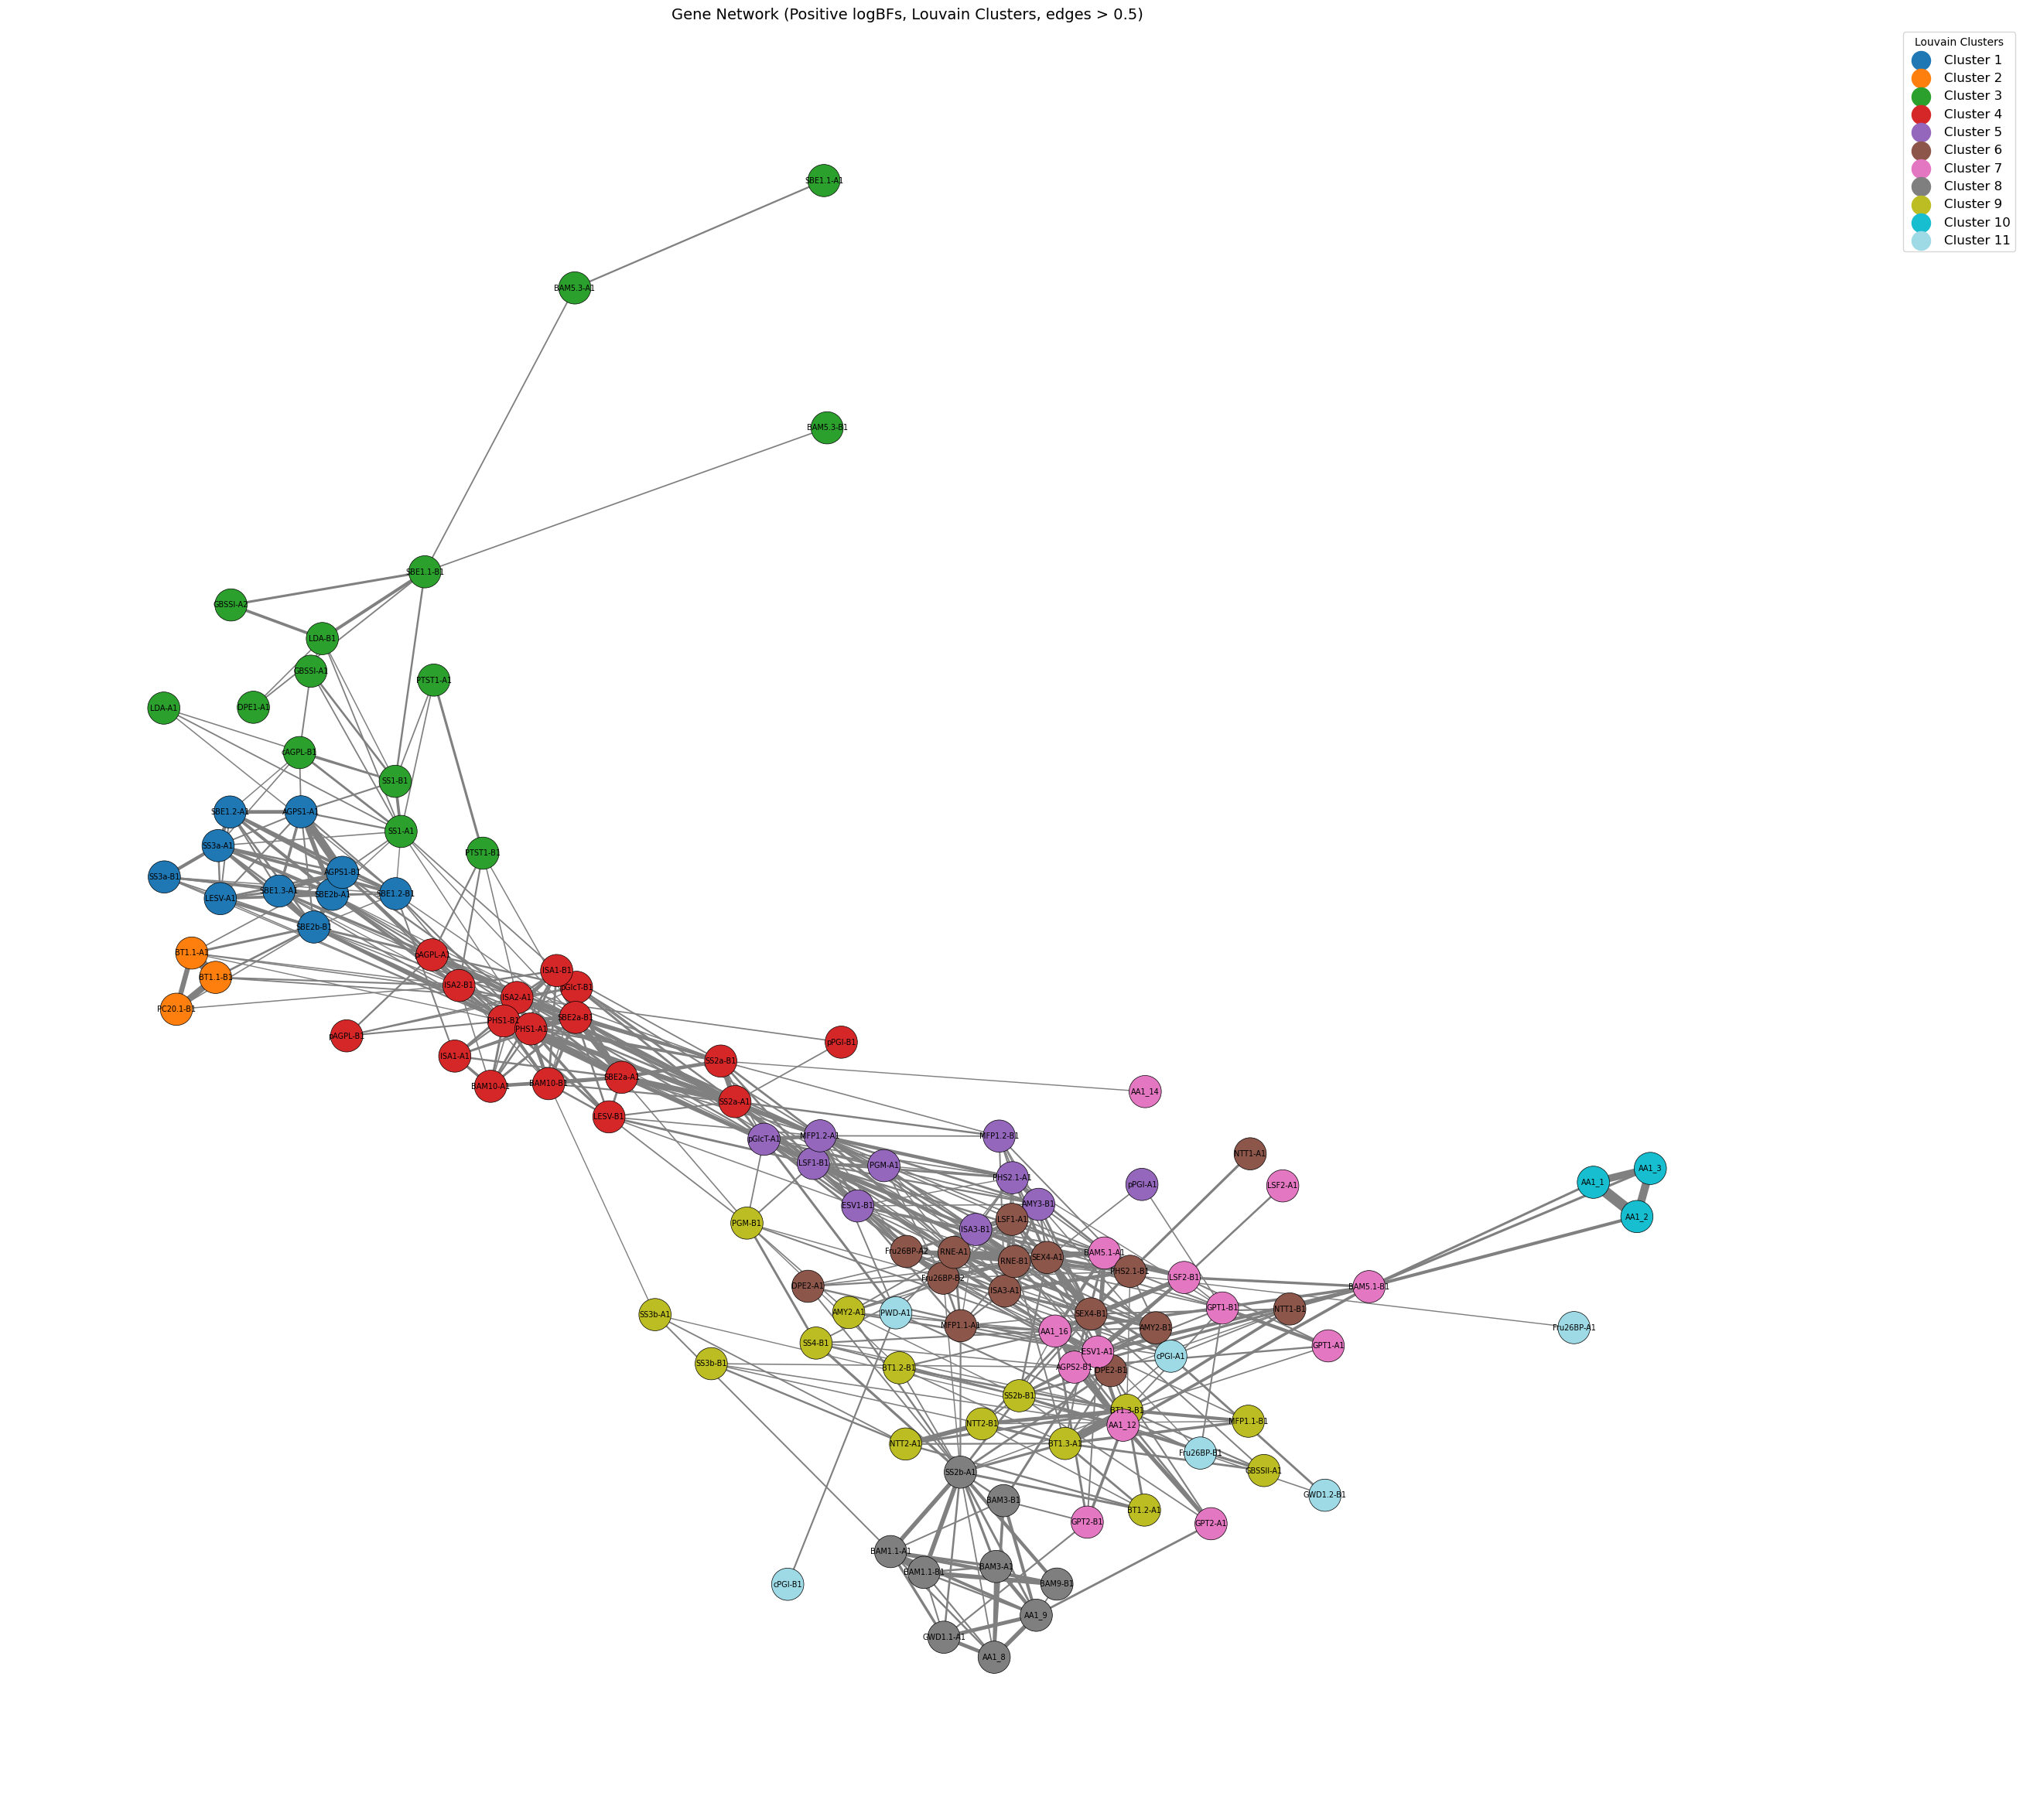

In [16]:
# -----------------------------
# User parameters
# -----------------------------
BF_threshold = 0.5  # only edges > BF_threshold are plotted

# -----------------------------
# Step 0: Prepare gene × gene matrix
# -----------------------------
# Remove 'cluster' column if it exists, clip negative logBFs
df_matrix = df_reordered_no_correct.drop(columns='cluster', errors='ignore').clip(lower=0)

# -----------------------------
# Step 1: Build network (all positive logBFs for clustering)
# -----------------------------
G = nx.Graph()
for i, row in enumerate(df_matrix.index):
    for j, col in enumerate(df_matrix.columns):
        if i < j:
            weight = df_matrix.iloc[i, j]
            if weight > 0:  # include all positive logBFs for clustering
                G.add_edge(row, col, weight=weight)

# -----------------------------
# Step 2: Add Gene_ID attributes
# -----------------------------
gene_id_map = dict(zip(sg_all['Transcript'], sg_all['Gene_ID']))
for node in G.nodes():
    G.nodes[node]['Gene_ID'] = gene_id_map.get(node, node)  # fallback to Transcript if missing

# -----------------------------
# Step 3: Louvain clustering
# -----------------------------
louvain_communities = nx.community.louvain_communities(G, weight='weight', seed=42, resolution=2)
partition = {}
for i, community_set in enumerate(louvain_communities, 1):
    for node in community_set:
        partition[node] = i
nx.set_node_attributes(G, partition, 'cluster')

# -----------------------------
# Step 4: Create cluster table and save CSV
# -----------------------------
cluster_table = pd.DataFrame({
    'Transcript': list(G.nodes()),
    'Gene_ID': [G.nodes[n]['Gene_ID'] for n in G.nodes()],
    'Louvain_cluster': [G.nodes[n]['cluster'] for n in G.nodes()]
})
cluster_table = cluster_table.sort_values('Louvain_cluster')
cluster_table.to_csv("louvain_clusters.csv", index=False)
print("Cluster table saved as 'louvain_clusters.csv'")
print(cluster_table.head())

# -----------------------------
# Step 5: Plot network (filtered by BF_threshold)
# -----------------------------
# Filter edges for plotting only
edges_to_draw = [(u, v, d) for u, v, d in G.edges(data=True) if d['weight'] > BF_threshold]

nodes_with_edges = set()
for u, v, d in edges_to_draw:
    nodes_with_edges.add(u)
    nodes_with_edges.add(v)

G_plot = G.subgraph(nodes_with_edges).copy()

pos = nx.spring_layout(G_plot, seed=42, k=0.35, iterations=100)

# Node colors by cluster
clusters = [G_plot.nodes[n]['cluster'] for n in G_plot.nodes()]
unique_clusters = sorted(set(clusters))
color_map = plt.cm.get_cmap('tab20', len(unique_clusters))
node_colors = [color_map(unique_clusters.index(c)) for c in clusters]

# Node labels from Gene_ID
labels = {n: G_plot.nodes[n]['Gene_ID'] for n in G_plot.nodes()}

# Edge widths scaled by weight
edge_widths = [2*d['weight'] for (_, _, d) in edges_to_draw]

plt.figure(figsize=(30, 30))
nx.draw_networkx_nodes(G_plot, pos, node_size=900, node_color=node_colors,
                       alpha=1, linewidths=0.5, edgecolors='black')
nx.draw_networkx_edges(G_plot, pos, edgelist=edges_to_draw, width=edge_widths,
                       alpha=1, edge_color='grey')
nx.draw_networkx_labels(G_plot, pos, labels=labels, font_size=7, font_color='black')

# Legend
cluster_color_map = {c: color_map(i) for i, c in enumerate(unique_clusters)}
for cluster, color in cluster_color_map.items():
    plt.scatter([], [], c=[color], label=f'Cluster {cluster}', s=300)
plt.legend(scatterpoints=1, fontsize=12, title='Louvain Clusters',
           bbox_to_anchor=(1.05, 1), loc='upper left')

plt.title(f'Gene Network (Positive logBFs, Louvain Clusters, edges > {BF_threshold})', fontsize=14)
plt.axis('off')
plt.savefig("gene_network_labels_greater05.svg", format="svg", bbox_inches="tight")
plt.show()

## plotting by colouring based on function 

/var/folders/ky/6fks9zq96wnc1dytmwwmkrrw000f76/T/ipykernel_67642/1383156360.py:32: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_map = plt.cm.get_cmap("tab20", len(unique_functions))


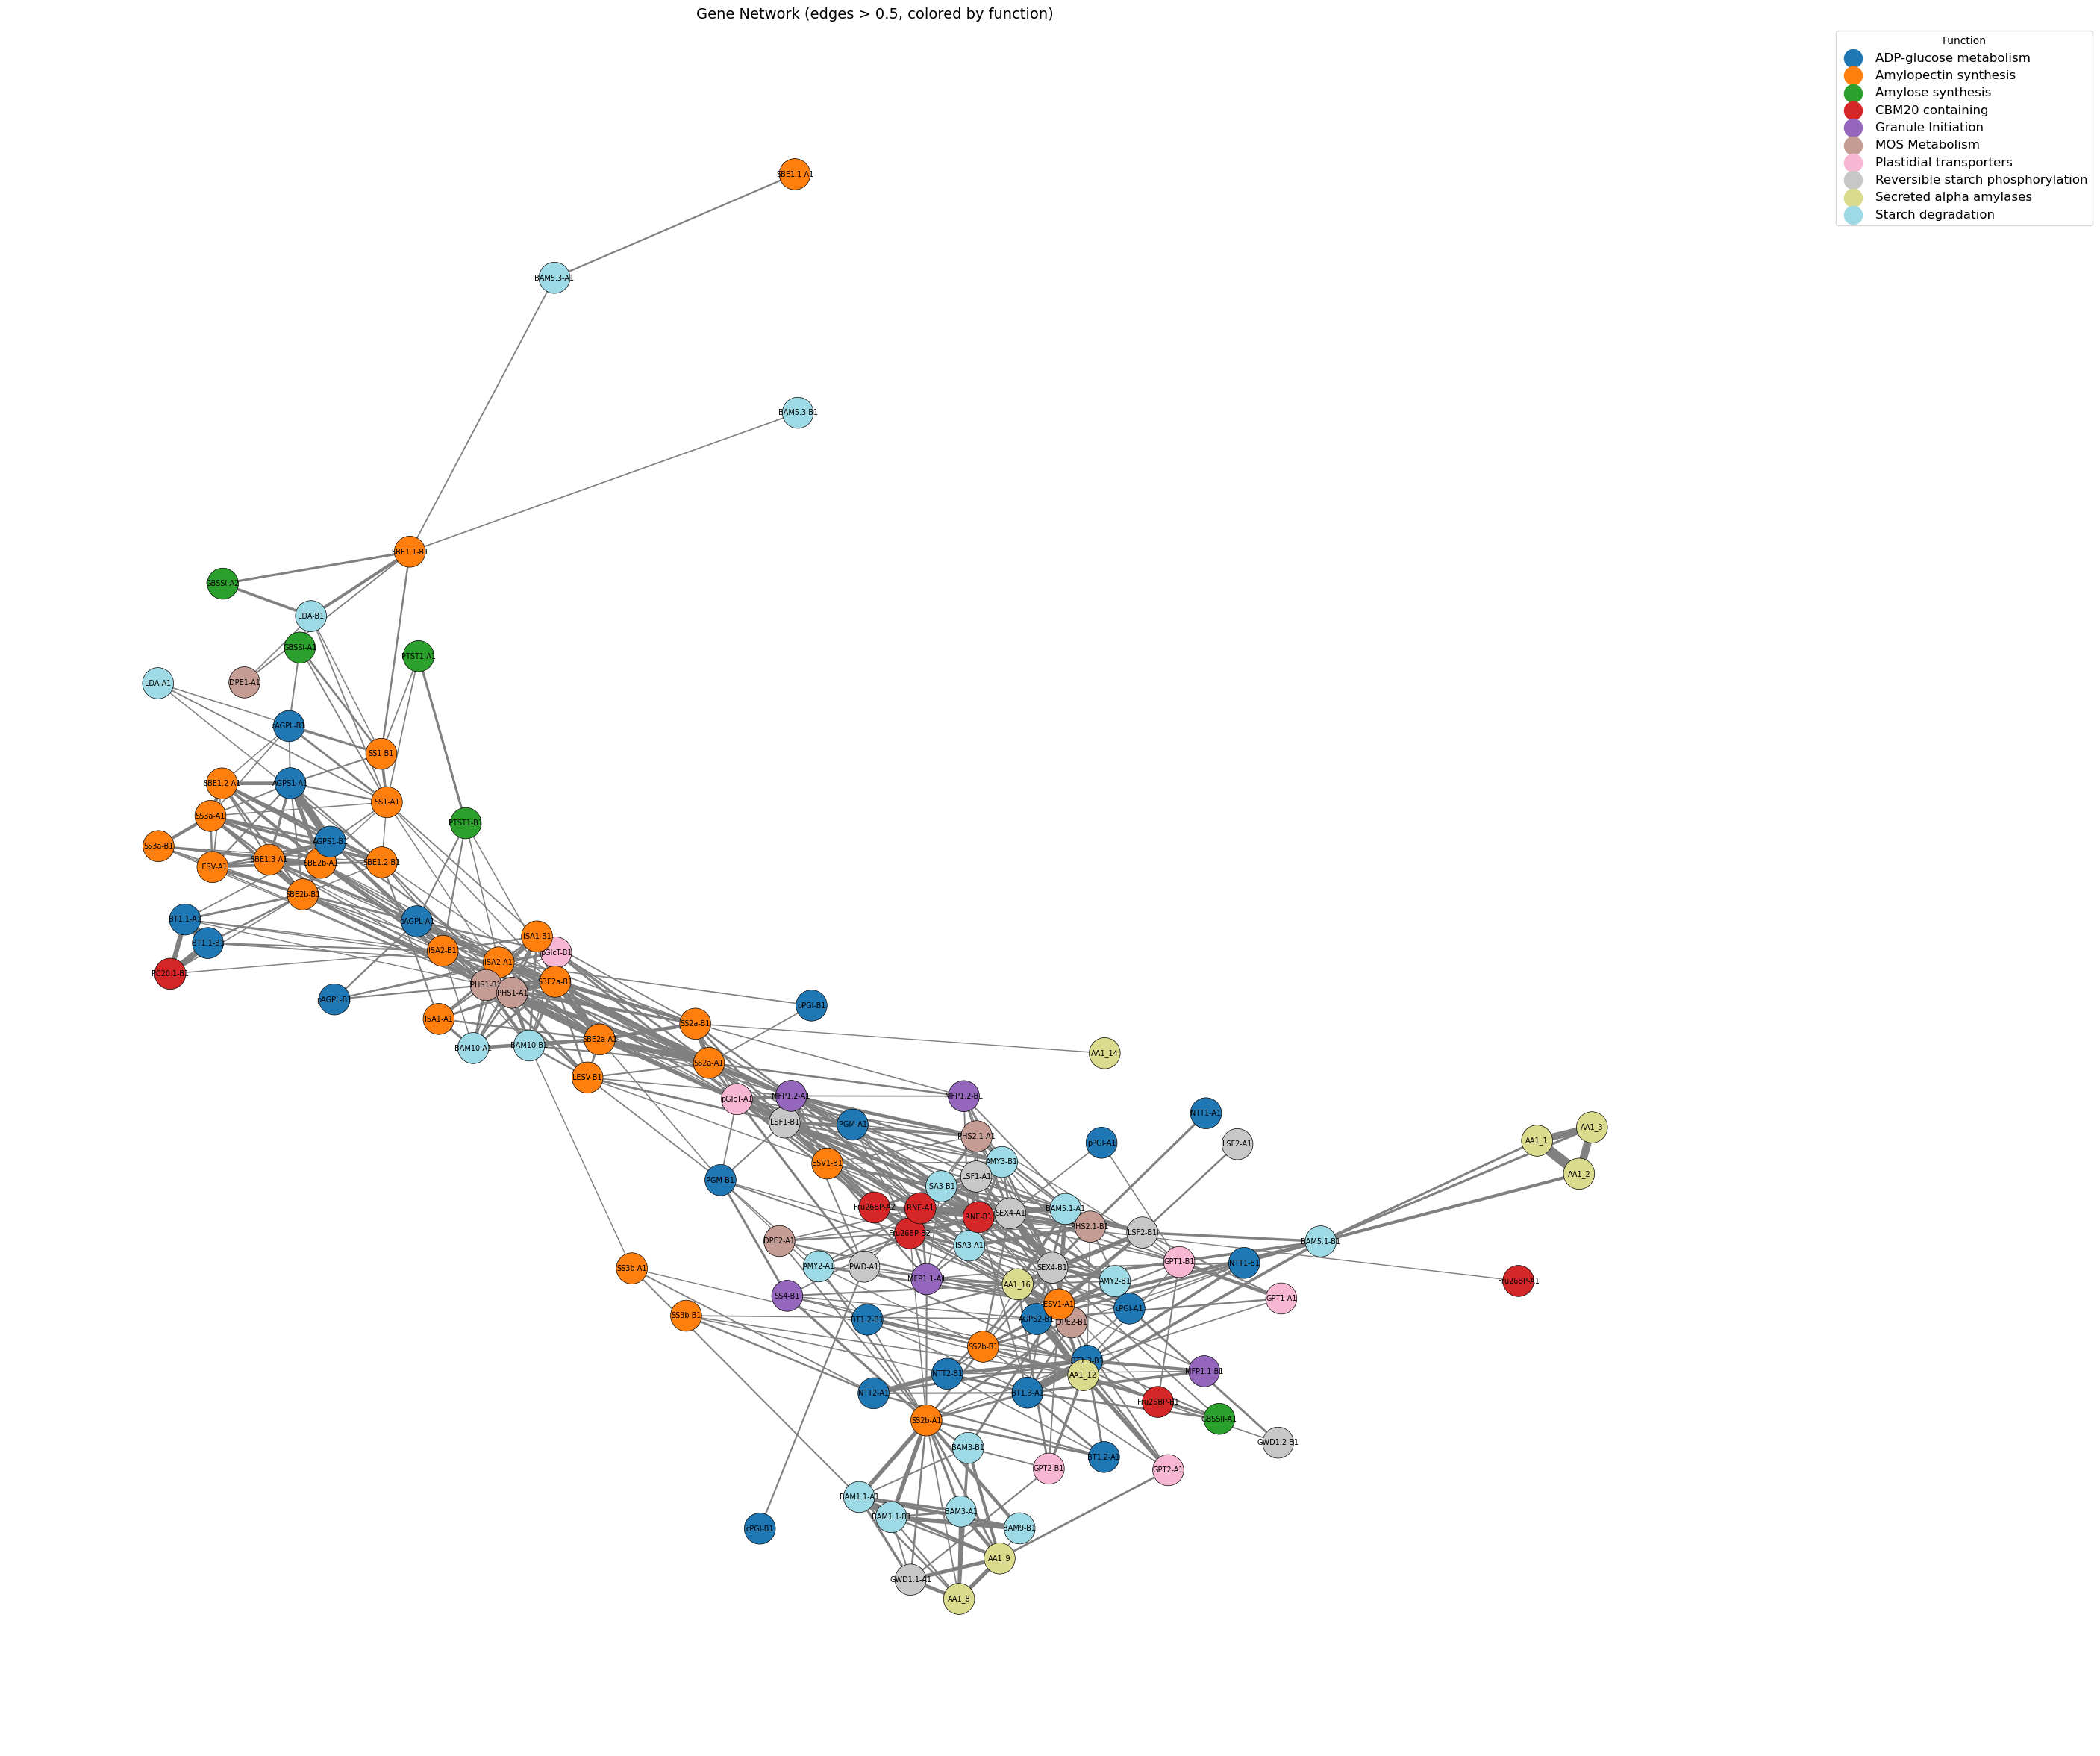

In [15]:
# -----------------------------
# User parameters
# -----------------------------
BF_threshold = 0.5  # only edges > BF_threshold are plotted

# -----------------------------
# Add "function" attribute from sg_all
# -----------------------------
function_map = dict(zip(sg_all["Transcript"], sg_all["function"]))

for node in G.nodes():
    G.nodes[node]["function"] = function_map.get(node, "Unknown")

# -----------------------------
# Plot network (colored by function)
# -----------------------------
edges_to_draw = [(u, v, d) for u, v, d in G.edges(data=True) if d["weight"] > BF_threshold]

nodes_with_edges = set()
for u, v, d in edges_to_draw:
    nodes_with_edges.add(u)
    nodes_with_edges.add(v)

G_plot = G.subgraph(nodes_with_edges).copy()

pos = nx.spring_layout(G_plot, seed=42, k=0.35, iterations=100)

# Node colors by function
functions = [G_plot.nodes[n]["function"] for n in G_plot.nodes()]
unique_functions = sorted(set(functions))

color_map = plt.cm.get_cmap("tab20", len(unique_functions))
node_colors = [color_map(unique_functions.index(f)) for f in functions]

# Labels still Gene_ID
labels = {n: G_plot.nodes[n]["Gene_ID"] for n in G_plot.nodes()}

# Edge widths
edge_widths = [2 * d["weight"] for (_, _, d) in edges_to_draw]

plt.figure(figsize=(30, 30))

nx.draw_networkx_nodes(
    G_plot, pos,
    node_size=900,
    node_color=node_colors,
    alpha=1,
    linewidths=0.5,
    edgecolors="black"
)

nx.draw_networkx_edges(
    G_plot, pos,
    edgelist=edges_to_draw,
    width=edge_widths,
    alpha=1,
    edge_color="grey"
)

nx.draw_networkx_labels(
    G_plot, pos,
    labels=labels,
    font_size=7,
    font_color="black"
)

# Legend for functions
function_color_map = {f: color_map(i) for i, f in enumerate(unique_functions)}
for func, color in function_color_map.items():
    plt.scatter([], [], c=[color], label=func, s=300)

plt.legend(
    scatterpoints=1,
    fontsize=12,
    title="Function",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.title(f"Gene Network (edges > {BF_threshold}, colored by function)", fontsize=14)
plt.axis("off")
plt.savefig("gene_network_functionlabels_greater05.svg", format="svg", bbox_inches="tight")
plt.show()

In [11]:
# -----------------------------
# User parameters
# -----------------------------
BF_threshold = 0  # only edges > BF_threshold are plotted

# -----------------------------
# Step 0: Prepare gene × gene matrix
# -----------------------------
# Remove 'cluster' column if it exists, clip negative logBFs
df_matrix = df_reordered_no_correct.drop(columns='cluster', errors='ignore').clip(lower=0)

# -----------------------------
# Step 1: Build network (all positive logBFs for clustering)
# -----------------------------
G = nx.Graph()
for i, row in enumerate(df_matrix.index):
    for j, col in enumerate(df_matrix.columns):
        if i < j:
            weight = df_matrix.iloc[i, j]
            if weight > 0:  # include all positive logBFs for clustering
                G.add_edge(row, col, weight=weight)

# -----------------------------
# Step 2: Add Gene_ID attributes
# -----------------------------
gene_id_map = dict(zip(sg_all['Transcript'], sg_all['Gene_ID']))
for node in G.nodes():
    G.nodes[node]['Gene_ID'] = gene_id_map.get(node, node)  # fallback to Transcript if missing

# -----------------------------
# Step 3: Louvain clustering
# -----------------------------
louvain_communities = nx.community.louvain_communities(G, weight='weight', seed=42, resolution=2)
partition = {}
for i, community_set in enumerate(louvain_communities, 1):
    for node in community_set:
        partition[node] = i
nx.set_node_attributes(G, partition, 'cluster')

# -----------------------------
# Step 4: Create cluster table and save CSV
# -----------------------------
cluster_table = pd.DataFrame({
    'Transcript': list(G.nodes()),
    'Gene_ID': [G.nodes[n]['Gene_ID'] for n in G.nodes()],
    'Louvain_cluster': [G.nodes[n]['cluster'] for n in G.nodes()]
})
cluster_table = cluster_table.sort_values('Louvain_cluster')
cluster_table.to_csv("louvain_clusters.csv", index=False)
print("Cluster table saved as 'louvain_clusters.csv'")
print(cluster_table.head())

# -----------------------------
# Step 5: Plot network (filtered by BF_threshold)
# -----------------------------
# Filter edges for plotting only
edges_to_draw = [(u, v, d) for u, v, d in G.edges(data=True) if d['weight'] > BF_threshold]

nodes_with_edges = set()
for u, v, d in edges_to_draw:
    nodes_with_edges.add(u)
    nodes_with_edges.add(v)

G_plot = G.subgraph(nodes_with_edges).copy()

pos = nx.spring_layout(G_plot, seed=42, k=0.35, iterations=100)

# Node colors by cluster
clusters = [G_plot.nodes[n]['cluster'] for n in G_plot.nodes()]
unique_clusters = sorted(set(clusters))
color_map = plt.cm.get_cmap('tab20', len(unique_clusters))
node_colors = [color_map(unique_clusters.index(c)) for c in clusters]

# Edge widths scaled by weight
edge_widths = [2*d['weight'] for (_, _, d) in edges_to_draw]

plt.figure(figsize=(30, 30))
nx.draw_networkx_nodes(G_plot, pos, node_size=900, node_color=node_colors,
                       alpha=1, linewidths=0.5, edgecolors='black')
nx.draw_networkx_edges(G_plot, pos, edgelist=edges_to_draw, width=edge_widths,
                       alpha=1, edge_color='grey')

# Legend
cluster_color_map = {c: color_map(i) for i, c in enumerate(unique_clusters)}
for cluster, color in cluster_color_map.items():
    plt.scatter([], [], c=[color], label=f'Cluster {cluster}', s=300)

plt.legend(scatterpoints=1, fontsize=12, title='Louvain Clusters',
           bbox_to_anchor=(1.05, 1), loc='upper left')

plt.title(f'Gene Network (Positive logBFs, Louvain Clusters, edges > {BF_threshold})', fontsize=14)
plt.axis('off')

# Save as SVG (no node labels)
plt.savefig("gene_network.svg", format="svg", bbox_inches="tight")
plt.close()

print("Network plot saved as 'gene_network.svg'")

Cluster table saved as 'louvain_clusters.csv'
             Transcript    Gene_ID  Louvain_cluster
0   TraesCS2A03G0772100   SBE2b-A1                1
19  TraesCS7A03G0682600   AGPS1-A1                1
24  TraesCS7B03G0513900   AGPS1-B1                1
25  TraesCS7B03G1269000  SBE1.2-B1                1
11  TraesCS4A03G0350000    LESV-A1                1
Network plot saved as 'gene_network.svg'


/var/folders/ky/6fks9zq96wnc1dytmwwmkrrw000f76/T/ipykernel_32296/1108131248.py:71: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_map = plt.cm.get_cmap('tab20', len(unique_clusters))
